In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

# Default figure settings
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [4]:
df = pd.read_csv("data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df["Age"].isnull().sum()

np.int64(0)

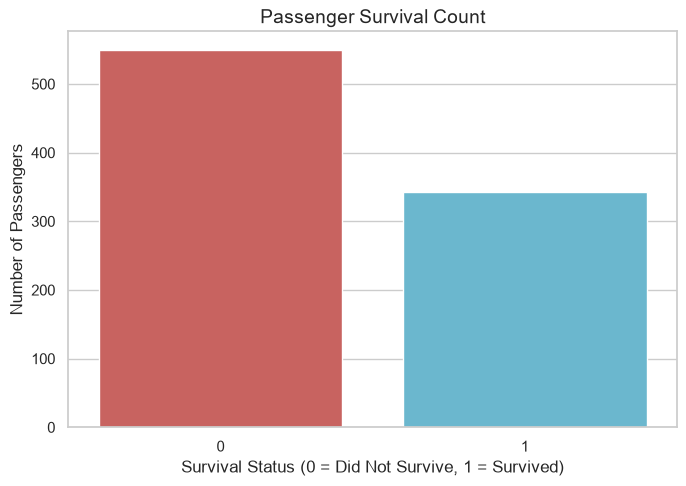

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Survived",
    hue="Survived",                 # Required for newer Seaborn versions
    palette=["#d9534f", "#5bc0de"],
    legend=False
)

plt.title("Passenger Survival Count", fontsize=14)
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

**Takeaway:** More passengers died than survived during the Titanic disaster.

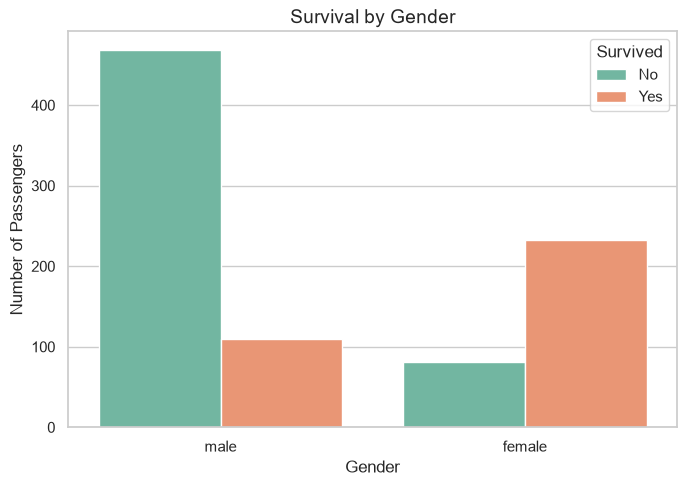

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived",
    palette="Set2"
)

plt.title("Survival by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

**Takeaway:** Female passengers had a much higher survival rate than male passengers.

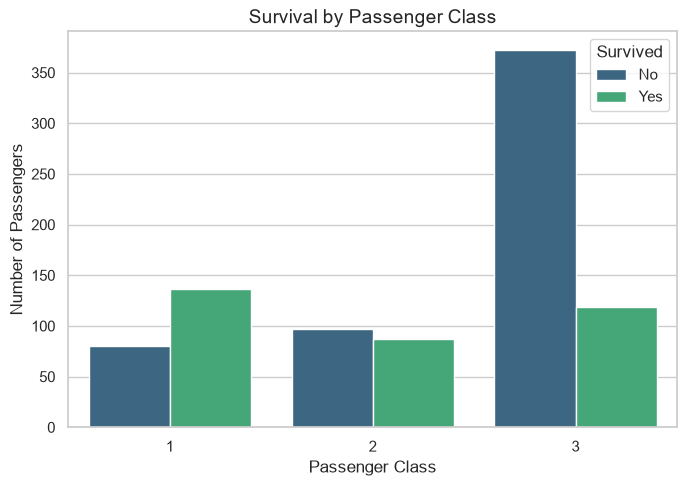

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived",
    palette="viridis"
)

plt.title("Survival by Passenger Class", fontsize=14)
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

**Takeaway:** First-class passengers had the highest survival rate, while third-class passengers had the lowest.

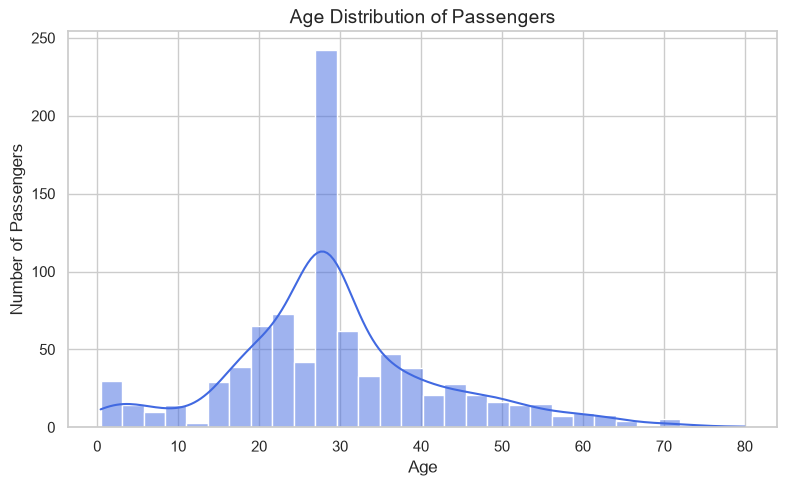

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Age Distribution of Passengers", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

**Takeaway:** Most passengers were young adults between 20 and 40 years old.

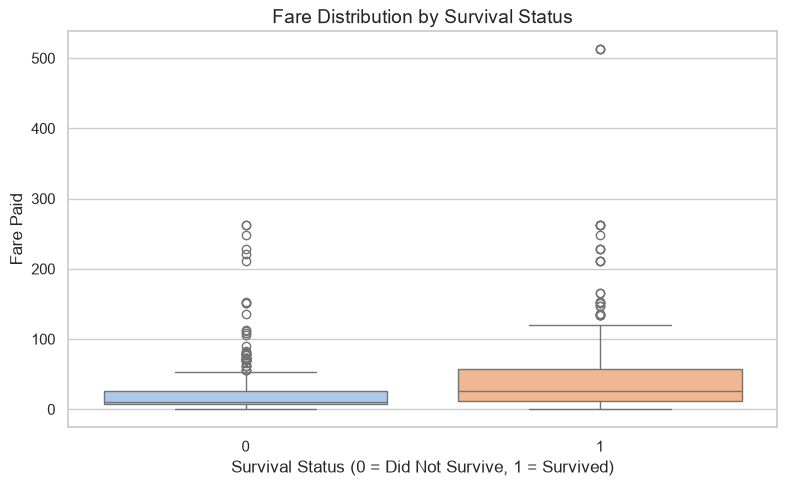

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare",
    hue="Survived",
    palette="pastel",
    legend=False
)

plt.title("Fare Distribution by Survival Status", fontsize=14)
plt.xlabel("Survival Status (0 = Did Not Survive, 1 = Survived)")
plt.ylabel("Fare Paid")

plt.tight_layout()
plt.show()

**Takeaway:** Passengers who survived generally paid higher fares than those who did not survive.

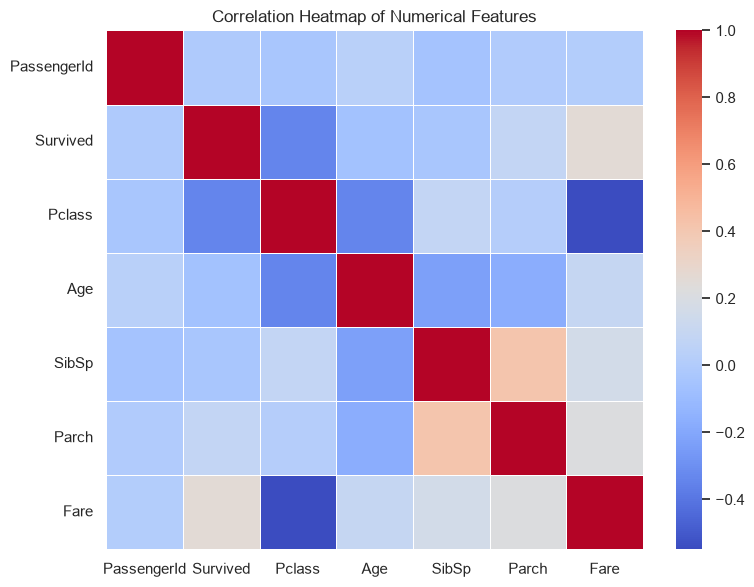

In [15]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

**Takeaway:** Passenger class and fare have noticeable relationships with survival, while age has a weaker correlation.

# Titanic Visual Story

This analysis explores the factors that influenced passenger survival aboard the Titanic using six visualizations. The survival count chart shows that more passengers lost their lives than survived. The gender analysis reveals that female passengers had a much higher survival rate than male passengers, reflecting the evacuation priority given to women and children.

Passenger class also played a significant role in survival. First-class passengers had the highest survival rate, while third-class passengers experienced the greatest loss of life. The age distribution shows that most passengers were young adults between 20 and 40 years old. The fare distribution indicates that passengers who paid higher fares were generally more likely to survive, suggesting that socioeconomic status influenced access to safety.

The correlation heatmap summarizes the relationships between the numerical variables and confirms that passenger class and fare are associated with survival. Age, while important in some cases, shows a weaker overall relationship.

Overall, this visual story demonstrates that survival on the Titanic was strongly influenced by gender, passenger class, and ticket fare rather than chance alone. These visualizations transform raw data into meaningful insights and clearly communicate the key factors that affected passenger survival.